# Phase 1: Data Collection & Understanding

In [41]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path

## 1. Import and load data

In [42]:
warnings.filterwarnings("ignore")

RAW_DIR = Path("../../data/raw/bls")

FILES = {
    2019: RAW_DIR / "oesm19nat.xlsx",
    2022: RAW_DIR / "oesm22nat.xlsx",
    2024: RAW_DIR / "oesm24nat.xlsx",
}

In [43]:
frames = []
for year, path in FILES.items():
    df = pd.read_excel(path, sheet_name=0)
    df.columns = df.columns.str.upper().str.strip()
    df["YEAR"] = year
    frames.append(df)

data = pd.concat(frames, ignore_index=True)

# Fields `PRIM_STATE` and `PCT_RPT` are not in 2019 file
missing_in_2019 = {"PRIM_STATE", "PCT_RPT"} - set(
    pd.read_excel(FILES[2019], sheet_name=0, nrows=0).columns.str.upper()
)

## 2. Understand data structure and format

In [44]:
print("== Shape ==")
print(f"Rows: {data.shape[0]:,}")
print(f"Columns: {data.shape[1]}")

== Shape ==
Rows: 4,134
Columns: 33


In [45]:
print("== First 5 rows ==")
data.head()

== First 5 rows ==


,AREA,AREA_TITLE,AREA_TYPE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,O_GROUP,...,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY,YEAR,PRIM_STATE,PCT_RPT
0,99,U.S.,1,0,Cross-industry,cross-industry,1235,00-0000,All Occupations,total,...,21530,27080,39810,64240,101020,NaN,NaN,2019,NaN,NaN
1,99,U.S.,1,0,Cross-industry,cross-industry,1235,11-0000,Management Occupations,major,...,49990,71460,105660,154260,#,NaN,NaN,2019,NaN,NaN
2,99,U.S.,1,0,Cross-industry,cross-industry,1235,11-1000,Top Executives,minor,...,43710,65910,103230,163970,#,NaN,NaN,2019,NaN,NaN
3,99,U.S.,1,0,Cross-industry,cross-industry,1235,11-1010,Chief Executives,broad,...,62290,112790,184460,#,#,NaN,NaN,2019,NaN,NaN
4,99,U.S.,1,0,Cross-industry,cross-industry,1235,11-1011,Chief Executives,detailed,...,62290,112790,184460,#,#,NaN,NaN,2019,NaN,NaN


In [46]:
print("== Data types & non-null counts ==")
data.info(show_counts=True)

== Data types & non-null counts ==
<class 'pandas.DataFrame'>
RangeIndex: 4134 entries, 0 to 4133
Data columns (total 33 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AREA          4134 non-null   int64  
 1   AREA_TITLE    4134 non-null   str    
 2   AREA_TYPE     4134 non-null   int64  
 3   NAICS         4134 non-null   int64  
 4   NAICS_TITLE   4134 non-null   str    
 5   I_GROUP       4134 non-null   str    
 6   OWN_CODE      4134 non-null   int64  
 7   OCC_CODE      4134 non-null   str    
 8   OCC_TITLE     4134 non-null   str    
 9   O_GROUP       4134 non-null   str    
 10  TOT_EMP       4134 non-null   int64  
 11  EMP_PRSE      4134 non-null   float64
 12  JOBS_1000     0 non-null      float64
 13  LOC_QUOTIENT  0 non-null      float64
 14  PCT_TOTAL     0 non-null      float64
 15  H_MEAN        4134 non-null   object 
 16  A_MEAN        4134 non-null   object 
 17  MEAN_PRSE     4134 non-null   float64
 18  H_PC

## 3. Identify variable types and definitions

In [47]:
variable_catalog = pd.DataFrame({
    "Column": data.columns,
    "Dtype": data.dtypes.values,
    "Non-Null": data.notna().sum().values,
    "Nunique": data.nunique().values,
    "Sample Value": [data[c].dropna().iloc[0] if data[c].notna().any() else np.nan for c in data.columns],
})

NOMINAL = [
    "AREA", "AREA_TITLE", "AREA_TYPE", "PRIM_STATE",
    "NAICS", "NAICS_TITLE", "I_GROUP", "OWN_CODE",
    "OCC_CODE", "OCC_TITLE", "O_GROUP", "ANNUAL", "HOURLY",
]
ORDINAL = [
    "O_GROUP",  # total > major > minor > broad > detailed
]
RATIO = [
    "TOT_EMP", "EMP_PRSE", "JOBS_1000", "LOC_QUOTIENT",
    "PCT_TOTAL", "PCT_RPT", "MEAN_PRSE",
    "H_MEAN", "A_MEAN",
    "H_PCT10", "H_PCT25", "H_MEDIAN", "H_PCT75", "H_PCT90",
    "A_PCT10", "A_PCT25", "A_MEDIAN", "A_PCT75", "A_PCT90",
]
INTERVAL = ["YEAR"]

def classify(col):
    if col in INTERVAL:
        return "Interval"
    if col in ORDINAL:
        return "Ordinal"
    if col in RATIO:
        return "Ratio"
    return "Nominal"

variable_catalog["Measurement Scale"] = variable_catalog["Column"].map(classify)
variable_catalog

,Column,Dtype,Non-Null,Nunique,Sample Value,Measurement Scale
0,AREA,int64,4134,1,99,Nominal
1,AREA_TITLE,str,4134,1,U.S.,Nominal
2,AREA_TYPE,int64,4134,1,1,Nominal
3,NAICS,int64,4134,1,0,Nominal
4,NAICS_TITLE,str,4134,1,Cross-industry,Nominal
5,I_GROUP,str,4134,1,cross-industry,Nominal
6,OWN_CODE,int64,4134,1,1235,Nominal
7,OCC_CODE,str,4134,1420,00-0000,Nominal
8,OCC_TITLE,str,4134,1162,All Occupations,Nominal
9,O_GROUP,str,4134,5,total,Ordinal


### Field Definitions

| Field | Description |
|---|---|
| `AREA` / `AREA_TITLE` / `AREA_TYPE` / `PRIM_STATE` | Geographic identifiers (all rows = U.S. national) |
| `NAICS` / `NAICS_TITLE` / `I_GROUP` | Industry classification (NAICS code, title, and level) |
| `OWN_CODE` | Ownership type (e.g., 1235 = all sectors combined) |
| `OCC_CODE` / `OCC_TITLE` | 6-digit SOC occupation code and title |
| `O_GROUP` | SOC hierarchy level: *total → major → minor → broad → detailed* |
| `TOT_EMP` | Estimated total employment (rounded to nearest 10) |
| `EMP_PRSE` / `MEAN_PRSE` | Percent relative standard error for employment / mean wage |
| `JOBS_1000` / `LOC_QUOTIENT` | Per-1000 employment rate and location quotient (blank for national) |
| `PCT_TOTAL` / `PCT_RPT` | % of industry employment; % of establishments reporting |
| `H_MEAN` / `A_MEAN` | Mean hourly / annual wage |
| `H_PCT10 … H_PCT90` | Hourly wage percentiles (10th, 25th, 50th, 75th, 90th) |
| `A_PCT10 … A_PCT90` | Annual wage percentiles |
| `ANNUAL` / `HOURLY` | Flag: TRUE if only annual or hourly wages are released |
| `YEAR` | Survey year (added during loading: 2019, 2022, 2024) |

**Note**:
- `'#'` = wage ≥ `$115`/hr or `$239,200`/yr
- `'*'` = not available
- `'**'` = employment not available

# Phase 2: Data Quality Assessment

In [48]:
import matplotlib.pyplot as plt

## 1. Check for missing values and duplicates

In [49]:
missing = data.isnull().sum()

print("== Missing values ==")
for col in missing[missing > 0].sort_values().index:
    print(f"{col:15s}  {missing[col]}")

== Missing values ==
PRIM_STATE       1329
ANNUAL           3886
HOURLY           4114
JOBS_1000        4134
LOC_QUOTIENT     4134
PCT_TOTAL        4134
PCT_RPT          4134


**Note**: Column `PRIM_STATE` absent in the 2019 file, added in 2022+

In [50]:
print(f"== Duplicate ==")
print(f"Exact duplicate rows:    {data.duplicated().sum()}")
print(f"Total rows:              {len(data):,}")
print(f"Unique OCC_CODEs:        {data['OCC_CODE'].nunique()}")
print(f"Unique (OCC_CODE, YEAR): {data.groupby(['OCC_CODE', 'YEAR']).ngroups}")

== Duplicate ==
Exact duplicate rows:    0
Total rows:              4,134
Unique OCC_CODEs:        1420
Unique (OCC_CODE, YEAR): 4107


**Note**: `(OCC_CODE, YEAR)` "duplicates" are not really duplicates. BLS publishes the same code at both the `broad` and `detailed` SOC levels. The `O_GROUP` column distinguishes them

## 2. Identify outliers and anomalies

In [51]:
WAGE_COLS = ["H_MEAN", "A_MEAN", "H_MEDIAN", "A_MEDIAN"]
NUM_COLS  = ["TOT_EMP", "EMP_PRSE", "MEAN_PRSE"]

wage_num = data[WAGE_COLS].apply(pd.to_numeric, errors="coerce")
check_cols = pd.concat([data[NUM_COLS], wage_num], axis=1)

def iqr_outliers(series):
    s = series.dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = s[(s < lower) | (s > upper)]
    return pd.Series({"Q1": Q1, "Q3": Q3, "IQR": IQR, "Lower": lower, "Upper": upper, "Outliers": len(outliers), "Outlier %": round(len(outliers) / len(s) * 100, 1)})

outlier_summary = check_cols.apply(iqr_outliers).T
outlier_summary

,Q1,Q3,IQR,Lower,Upper,Outliers,Outlier %
TOT_EMP,21030.0000,276947.50,255917.5000,-362846.25000,660823.75000,540.0,13.1
EMP_PRSE,1.0000,3.70,2.7000,-3.05000,7.75000,269.0,6.5
MEAN_PRSE,0.4000,1.40,1.0000,-1.10000,2.90000,278.0,6.7
H_MEAN,20.7225,38.63,17.9075,-6.13875,65.49125,205.0,5.3
A_MEAN,43702.5000,83257.50,39555.0000,-15630.00000,142590.00000,183.0,4.4
H_MEDIAN,19.0100,34.67,15.6600,-4.48000,58.16000,209.0,5.4
A_MEDIAN,40020.0000,74697.50,34677.5000,-11996.25000,126713.75000,172.0,4.2


**Note:** Outliers here shows the natural skew of labor data, represents a few very large occupations and high-paying roles. It's not data errors so no removal is needed at this stage

## 3. Assess data completeness and consistency

In [52]:
data.groupby("YEAR")["OCC_CODE"].nunique()

YEAR
2019    1316
2022    1395
2024    1396
Name: OCC_CODE, dtype: int64

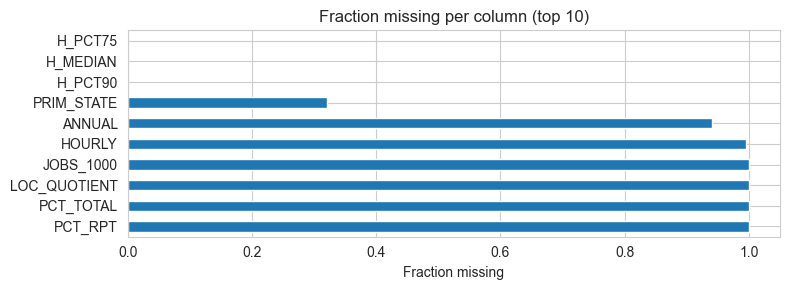

In [53]:
data.isnull().mean().sort_values(ascending=False).head(10).plot.barh(figsize=(8, 3), title="Fraction missing per column (top 10)")
plt.xlabel("Fraction missing")
plt.tight_layout()
plt.show()